# Tutorial 1: Your First Sea-Level Fingerprint

Welcome to `pyslfp`! In this tutorial, we will compute our very first **sea-level fingerprint**—the distinct, non-uniform spatial pattern of sea-level change that occurs when a specific ice sheet melts. 

When a massive ice sheet loses mass, two major things happen: its gravitational pull on the surrounding ocean weakens, and the solid Earth beneath it elastically rebounds. Counter-intuitively, this causes sea levels to actually *fall* near the melting ice, while rising significantly higher than the global average much further away.

Let's start by importing `matplotlib` for plotting and `pyslfp` for the physics. The cell below will automatically install `pyslfp` if you are running this in a cloud environment like Google Colab.

In [1]:
# import the libraries either locally or installing when on colab
import matplotlib.pyplot as plt

try:
    import pyslfp as sl
except ImportError: 
    %pip install pyslfp --quiet
    import pyslfp as sl

### Setting up the Physics Engine

At the heart of `pyslfp` is the Sea Level Equation (SLE) solver. The SLE is a complex integro-differential equation that balances mass conservation, Earth's elastic deformation, and changes to the gravitational field.

For this tutorial, we will use the `LinearSeaLevelEquation`. This version assumes a fixed shoreline (meaning it doesn't account for ocean migrating over land or retreating), which is a standard assumption for modern-day and short-term future sea-level projections. 

To make things easy, we can initialize it with `.from_defaults()`, which automatically loads standard parameters for a realistic Earth model (based on the Preliminary Reference Earth Model, or PREM) along with ice and sea level data for the present day from Ice-7g. 

In [ ]:
# Set up the sea level equation solver using default parameters
sle = sl.LinearSeaLevelEquation.from_defaults(lmax=64)

### Generating the Melt Load

Before we can solve the Sea Level Equation, we need to define our perturbation—the "load." In glacial isostatic adjustment (GIA), a load is a change in mass at the Earth's surface. 

In this scenario, we want to simulate melting 10% of the West Antarctic Ice Sheet. The solver's internal `state` object contains a suite of convenience methods to instantly generate scientifically accurate spatial masks and mass loads for major ice sheets and regional drainage basins. Let's create our direct mass load.

In [3]:
# Generate the direct load corresponding to melting a fraction of the West Antarctic.
direct_load = sle.state.west_antarctic_load(fraction=0.1)

### Solving the Sea Level Equation

Now that we have our physical Earth model and our surface mass load, we are ready to solve the Sea Level Equation! 

The `solve_sea_level_equation` method returns four distinct physical responses:
1. Relative sea-level change
2. Solid Earth vertical displacement
3. Gravitational potential change
4. Angular velocity change (polar wander)

For this tutorial, we are only interested in the final relative sea-level change, so we will capture the first output and ignore the rest.

In [4]:
# Get the change in sea level, ignoring other outputs in this case. 
sea_level_change, _, _, _ = sle.solve_sea_level_equation(direct_load)

### Visualizing the Fingerprint

Finally, let's plot our results. 

There are two important things to note about the plotting code below:
1. **Masking:** We multiply our result by `sle.state.ocean_projection()` to mask out the continents and so emphasise directly observable changes. 
2. **Dimensionalization:** To keep the math stable, the `pyslfp` physics engine calculates everything in non-dimensional units. To plot the results in actual meters, we simply multiply the output by the Earth model's `length_scale`.

Let's use the built-in `create_map_figure` and `plot` functions to see the fingerprint!

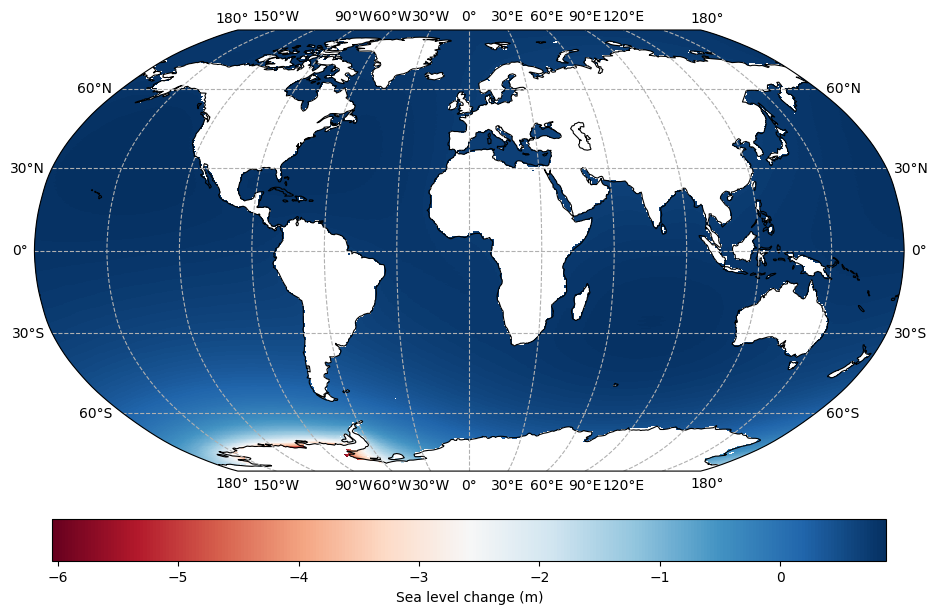

In [5]:
# Make a plot of the sea level change, dimensionalising the values, and 
# showing the field only over the oceans

_, ax = sl.create_map_figure(figsize=(12,6))

sl.plot(
    sea_level_change 
    * sle.state.ocean_projection() 
    * sle.state.model.parameters.length_scale, 
    ax=ax, 
    colorbar_kwargs={"label": "Sea level change (m)"}, 
    )


plt.show()

### Conclusion

Congratulations! You've just calculated a sea-level fingerprint. Notice the distinct pattern: sea levels actually drop near the West Antarctic, but rise significantly higher than the global average in the Northern Hemisphere.

**Next steps:** Try changing the `west_antarctic_load` to `greenland_load` in the cell above, re-run the notebook, and observe how the fingerprint changes!